### Using Kmeans Clustering to Find Ideal Team Additions
A report for Mr. Rooney and definitely not an assignment for any sort of machine learning class

In [48]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns

I started my exploration with two datasets- one with the salaries of players and one with their performance stats from teh 2024-2025 regular season. I merged these datasets together so I could understand more about how salary is determined.

In [49]:
#read the data in
salaries = pd.read_csv('/workspaces/DS-3021/10_kMeans Clustering/bball_salary.csv')
performance = pd.read_csv('/workspaces/DS-3021/10_kMeans Clustering/performance.csv')
#merge the datasets
nba = pd.merge(salaries, performance, on='Player')
#convert column for salary to a numeric
nba['2024-25'] = nba['2024-25'].str.replace('$', '')
nba['2024-25'] = nba['2024-25'].astype('float64')

The performance dataset I used had upwards of 30 performance metrics, but considering all of them would over-complicate my search. I decided to use the following metrics to help understand salary and performance:
* A player's rank in the NBA (Rk_y)
* The number of 2 point field goals the player made (2P)
* The number of free throws they made (FT)
* The number of points they scored (PTS)
* The number of defensive rebounds they made (DRB)

I chose these top four metrics because they were the most highly correlated with salary. You can see their correlations in the heat map below. The last metric, defensive rebounds, was included because I wanted to take into account not just offensive assets, but defensive ones too. 

<Axes: >

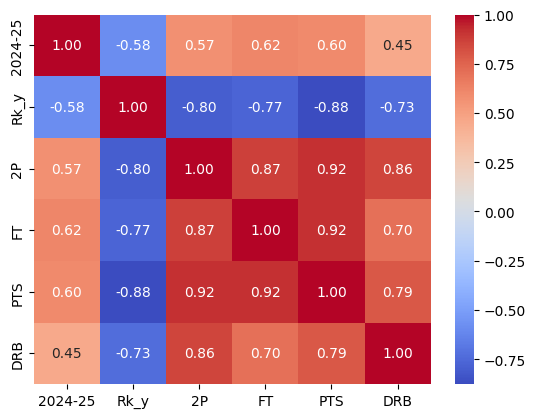

In [50]:
#create a heatmap of my chosen variables
nba = nba[['2024-25', 'Rk_y','2P', 'FT', 'PTS', 'DRB', 'Player']]
sns.heatmap(nba.select_dtypes(include='float64').corr(), annot=True, fmt='.2f', cmap='coolwarm')

Note that the column on the left shows each variable's correlation with salary (2024-25)

After I selected these variables to guide my exploration, I wanted to take a step back from salary and try and gauge players' overall performance. I did this using a method called kmeans clustering, which essentially takes data points and puts them into groups based on proximity.

The biggest decision when it comes to clustering is how many clusters you want to have. Splitting our data into 2 clusters would yield the most separate, cohesive groups (I calculated something called a silhouette score to confirm this). That said, having 3 or 4 clusters still accounted for variance in the data while giving me multiple distinct categories (I measured this using a metric called sum of squared errors). In our case, 2 clusters wouldn't be very helpful.

I ultimately decided to create 4 clusters of players, these representing great players, pretty good players, so-so players, and poor players.

In [51]:
#scale all the variables- I do this so they all have an equal effect on the cluster
scaler = MinMaxScaler()
nba[['PTS', 'Rk_y', '2P', 'FT', 'DRB']] = scaler.fit_transform(nba[['PTS', 'Rk_y', '2P', 'FT', 'DRB']])

In [52]:
#clustering the players
cluster_data = nba[['PTS', 'Rk_y', '2P', 'FT', 'DRB']]
kmeans_4 = KMeans(n_clusters=4, random_state=1).fit(cluster_data)
#visualizing the clusters
px.scatter(nba, x='PTS', y='Rk_y', color = kmeans_4.labels_)

Even though I used 5 performance metrics to make my clusters, you can still see them clump together pretty clearly when a plot the points only based on rank and points. The players are classified as follows:
* Great - orange
* Pretty good - yellow
* So-so - purple
* Poor - blue

I can confirm that these 4 clusters explain 87% of the variance (i.e. complexity) of our data.

In [53]:
#calculate the total sum of squares
total_sum_squares = np.sum((cluster_data - np.mean(cluster_data))**2)
total = np.sum(total_sum_squares)
#calculate the sum of squares between clusters
between_SSE = (total-kmeans_4.inertia_)
#use both those variable to find the explained variance
Var_explained = between_SSE/total
print("Variance explained: ", Var_explained)

Variance explained:  0.8662000572156785


/workspaces/DS-3021/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



I can also confirm that these clusters are actually informative of overall performance. The average performance metrics for each cluster is displayed below. An average close to 1 means that the players in that cluster have a really high value in this variable, while closer to 0 indicates a smaller value.

In [54]:
# Create a DataFrame for the cluster centers
cluster_centers_df = pd.DataFrame(kmeans_4.cluster_centers_, 
                                  columns=['PTS', 'Rk_y', '2P', 'FT', 'DRB'])

# Add a column for cluster labels
cluster_centers_df.index.name = 'Cluster'
cluster_centers_df.reset_index(inplace=True)

#name the clusters 
custom_cluster_names = {
    2: 'Great Players',
    3: 'Pretty Good Players',
    1: 'So-So Players',
    0: 'Poor Players'
}
cluster_centers_df['Cluster Name'] = cluster_centers_df['Cluster'].map(custom_cluster_names)

#drop columns and reorder them so we only see the understandable label of the cluster
new_column_order = ['Cluster Name', 'PTS', 'Rk_y', '2P', 'FT', 'DRB']
cluster_centers_df = cluster_centers_df[new_column_order]

#reorder rows to it makes sense 
cluster_centers_df = cluster_centers_df.sort_values(by='PTS', ascending=False)

# Print the labeled table
cluster_centers_df

,Cluster Name,PTS,Rk_y,2P,FT,DRB
2,Great Players,0.590703,0.062718,0.512485,0.445548,0.534325
3,Pretty Good Players,0.332344,0.204175,0.252843,0.195051,0.314352
1,So-So Players,0.156382,0.427789,0.119273,0.084926,0.184764
0,Poor Players,0.040741,0.726833,0.031353,0.020457,0.055489


Now, to make decisions about players, we can bring the component of salary back in. Ideally we can find some great players that are underpaid and get them to play on our team.

Instead of looking at salary continuously, i just chunked it into pay-brackets to make things more understandable.

In [55]:
#turn salary into a categorical variable
nba['salary_tier']= pd.qcut(nba['2024-25'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])

Below is the same graph from earlier that displayed our clusters, but this time different shapes are used to indicate paygrade. 

In [56]:
px.scatter(nba, x='PTS', y='Rk_y', color = kmeans_4.labels_, symbol='salary_tier')

This exposes the fact that performance level does not always correlate to salary. Yes, we can see that the well paid circle points are the majority of our well performing cluster, but we can spot outliers among the majorities. 

In [57]:
#create a dataframe with each player's assigned performance cluster and paygrade
data = {
    'Player': nba['Player'],
    'Cluster': kmeans_4.labels_,
    'Paygrade': nba['salary_tier']
}

preformance_sal_df = pd.DataFrame(data)

I looked at specific combinations between paygrades and performance clusters to determine which players are best for our team.

4 options that are not good choices:
- Ben Simmons
- Lonzo Ball
- Marcus Smart
These three players were all in the poor performing cluster despite being paid very paid well. This means that we'd have to pay a lot to get them on our team, but they wouldn't even be very good.

3 options that are great choices
- Jalen Williams
- Jalen Duren
- Christian Braun
All these players were in the high performing clusters, but only in medium-low paygrades. This means they'd be great at basketball, and we could still afford them.

4 backup options:
- Keon Johnson
- Scotty Pippen Jr.
- Tyus Jones
- Guerschon Yabusele
These players are above average but not amazing, and not currently paid very well. They wouldn't break the bank, and they would likely help our team.

In [58]:
#find great players in medium-low paygrade
great_players = preformance_sal_df[preformance_sal_df['Cluster']==2]
great_med_low = great_players[great_players['Paygrade']=='Med-Low']
great_med_low

,Player,Cluster,Paygrade
319,Jalen Williams,2,Med-Low
326,Jalen Duren,2,Med-Low
377,Christian Braun,2,Med-Low


In [59]:
#find poor players that are already paid too highly
poor_players = preformance_sal_df[preformance_sal_df['Cluster']==0]
poor_high = poor_players[poor_players['Paygrade'] == 'High']
poor_high

,Player,Cluster,Paygrade
36,Ben Simmons,0,High
103,Lonzo Ball,0,High
105,Marcus Smart,0,High
106,Marcus Smart,0,High
150,Mitchell Robinson,0,High
576,Ben Simmons,0,High


In [47]:
#find players that are pretty good, but in the low paygrade
pgood_players = preformance_sal_df[preformance_sal_df['Cluster']==3]
pgood_low = pgood_players[pgood_players['Paygrade']=='Low']
pgood_low

,Player,Cluster,Paygrade
445,Keon Johnson,3,Low
460,Scotty Pippen Jr.,3,Low
475,Tyus Jones,3,Low
480,Guerschon Yabusele,3,Low
488,Gary Trent Jr.,3,Low
489,Taurean Prince,3,Low
503,Spencer Dinwiddie,3,Low
510,Andrew Nembhard,3,Low
527,Toumani Camara,3,Low
535,Jalen Wilson,3,Low
